# **Guió desafiament Nº1** 

Basado en la información del dataset ***Bank Marketing*** una vez limpiado = (https://github.com/ITACADEMYprojectes/ProjecteData/blob/Equip_23/Equip_23/Data/Bank_Marketing_Cleaned.csv)"

**Pregunta para Analistes de Màrqueting i Comunicació:**

Quina relació hi ha entre el nombre de contactes realitzats durant aquesta campanya i la taxa d'èxit, i com podem optimitzar la freqüència de contacte per maximitzar els resultats de les nostres campanyes de màrqueting? 

### Cargamos el dataset


In [1]:
import pandas as pd

df = pd.read_csv(r"c:\Users\Portátil\ProjecteData\Equip_23\Data\23 February\Bank_Marketing_Cleaned-23_February.csv")
df.head()

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,1,59,admin.,married,secondary,no,2343,yes,no,unknown,5,5,1042,1,-1,0,unknown,yes
1,2,56,admin.,married,secondary,no,45,no,no,unknown,5,5,1467,1,-1,0,unknown,yes
2,3,41,technician,married,secondary,no,1270,yes,no,unknown,5,5,1389,1,-1,0,unknown,yes
3,4,55,services,married,secondary,no,2476,yes,no,unknown,5,5,579,1,-1,0,unknown,yes
4,5,54,admin.,married,tertiary,no,184,no,no,unknown,5,5,673,2,-1,0,unknown,yes


Consideramos que en el dataset hay dos variables importantes para responder a la pregunta planteada a los analistas de marketing y comunicación: “campaign” y “deposit”.Aprofundimos más en el estudio de estas variables para conocer mejor su composición y la relación existente entre ambas.

### Distribución del número de contactos realizados por cliente en la campaña

In [4]:
import pandas as pd
import plotly.express as px

# Contar registros por campaña
counts = df['campaign'].value_counts().sort_index()
counts= counts[counts.index<=5]
# Convertir a DataFrame
funnel_df = counts.reset_index()
funnel_df.columns = ['Contacto', 'clientes']

# Crear embudo
fig = px.funnel(funnel_df, x='clientes', y='Contacto',
                title="Distribución del número de contactos realizados por cliente en la campaña (hasta 5 contactos)")
fig.show()


### Número de clientes que adquirieron o no el depósito

In [11]:
counts= df['deposit'].value_counts().sort_index()
fig = px.pie(
    names=counts.index,
    values=counts.values,
    title='Proporción de clientes que han adquirido o no el dipósito'
)
fig.show()

### Distribución de contactos entre clientes que han adquirido el depósito



Determinación de cuantos contactos recibieron los clientes antes de adquirir el producto bancario

In [6]:
import plotly.express as px
import numpy as np

df_yes = df[df['deposit'] == 'yes']

# Valores estadísticos
min_val = df_yes['campaign'].min()
q1 = df_yes['campaign'].quantile(0.25)
median = df_yes['campaign'].median()
q3 = df_yes['campaign'].quantile(0.75)

# Fences para detectar outliers
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr
max_val = df_yes['campaign'].max()


df_yes = df[df['deposit'] == 'yes']

fig = px.box(
    df_yes,
    x='campaign',
    title='Distribución de contactos entre clientes que han adquirido el depósito'
)
fig.add_annotation(x=min_val, y=-0.25, text=f"Mínim: {min_val}", showarrow=True, arrowhead=1)
fig.add_annotation(x=q1, y=-0.15, text=f"Q1: {q1:.2f}", showarrow=True, arrowhead=1)
fig.add_annotation(x=median, y=-0.05, text=f"Mediana: {median:.2f}", showarrow=True, arrowhead=1)
fig.add_annotation(x=q3, y=0.05, text=f"Q3: {q3:.2f}", showarrow=True, arrowhead=1)
fig.add_annotation(x=upper_fence, y=0.15, text=f"Upper fence: {upper_fence:.2f}", showarrow=True, arrowhead=1)
fig.add_annotation(x=max_val, y=0.25, text=f"Màxim: {max_val}", showarrow=True, arrowhead=1)

fig.update_layout(
    margin=dict(l=40, r=40, t=40, b=60)
)

fig.show()


### Porcentaje de exito según el número de llamadas

Alto porcentaje de aceptación en las 3 primeras llamadas; a partir de ahí la tasa cae de forma progresiva y las conversiones se vuelven muy bajas.

In [7]:
success_rate = df.groupby('campaign')['deposit'].apply(lambda x: (x=='yes').mean() * 100)
print(success_rate)

campaign
1     55.770906
2     48.561525
3     49.203822
4     42.780027
5     39.044944
6     37.551020
7     36.718750
8     26.446281
9     30.434783
10    27.450980
11    41.025641
12    14.814815
13    20.000000
14    28.571429
15    33.333333
16    25.000000
17    46.153846
18     0.000000
19     0.000000
20    25.000000
21    14.285714
22     0.000000
23     0.000000
24    20.000000
25     0.000000
26     0.000000
27     0.000000
28     0.000000
29    50.000000
30     0.000000
31     0.000000
32    50.000000
33     0.000000
41     0.000000
43     0.000000
63     0.000000
Name: deposit, dtype: float64


### Número de clientes según el número de llamadas realizadas (1–10)

Vemos que, a partir de las 10 llamadas a un mismo cliente, el éxito cae por debajo del 30%; por tanto, acotamos la muestra.

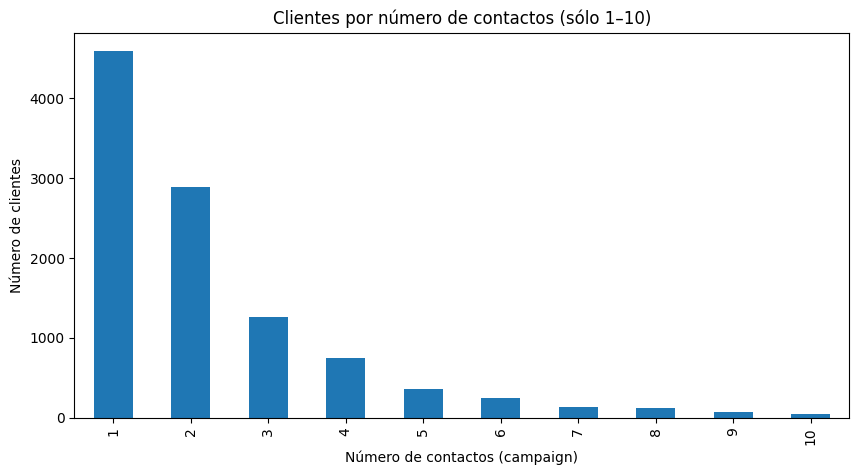

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

df['campaign'].value_counts().sort_index().loc[1:10].plot(
    kind='bar',
    figsize=(10,5)
)

plt.xlabel('Número de contactos (campaign)')
plt.ylabel('Número de clientes')
plt.title('Clientes por número de contactos (sólo 1–10)')
plt.show()

### Correlación entre variables

In [8]:
# crear columna numérica (yes=1, no=0) para trabajar con correlaciones
df['deposit_numeric'] = df['deposit'].map({'yes': 1, 'no': 0})



In [9]:
correlation = df['campaign'].corr(df['deposit_numeric'])
print("Correlation:", correlation)

Correlation: -0.13099512785187523


La correlación negativa (–0.13) indica que, en general, aumentar el número de llamadas reduce ligeramente la probabilidad de aceptació.

### Análisis de conversión por frecuencia de contacto

In [9]:
# Cálculo de la tasa de éxito por número de llamadas
success_rate = df.groupby('campaign')['deposit'].apply(lambda x: (x=='yes').mean())

# Cálculo de los intentos necesarios
intentos_necesario = 1 / success_rate

# Construcción de la tabla final
tabla_conversion = pd.DataFrame({
    'tasa_exito_%': success_rate * 100,
    'tasa_decimal': success_rate,
    'intentos_necesarios': intentos_necesario
})

# Mostrar la tabla ordenada por número de llamadas
print(tabla_conversion.sort_index().head(15))

          tasa_exito_%  tasa_decimal  intentos_necesarios
campaign                                                 
1            55.770906      0.557709             1.793050
2            48.561525      0.485615             2.059243
3            49.203822      0.492038             2.032362
4            42.780027      0.427800             2.337539
5            39.044944      0.390449             2.561151
6            37.551020      0.375510             2.663043
7            36.718750      0.367188             2.723404
8            26.446281      0.264463             3.781250
9            30.434783      0.304348             3.285714
10           27.450980      0.274510             3.642857
11           41.025641      0.410256             2.437500
12           14.814815      0.148148             6.750000
13           20.000000      0.200000             5.000000
14           28.571429      0.285714             3.500000
15           33.333333      0.333333             3.000000


### Tasa de éxito por tipo de contacto

In [10]:
import pandas as pd

# taxa d'èxit per tipus de contacte
df.groupby('contact')['deposit'].value_counts(normalize=True).unstack().round(2)*100


deposit,no,yes
contact,,
cellular,43.0,57.0
telephone,47.0,53.0
unknown,76.0,24.0


### Canales que funcionan mejor dentro las 3 primeros contactos

In [23]:
df_3 = df[df['campaign'] <= 3]

df_3.groupby(['campaign', 'contact'])['deposit'].value_counts(normalize=True).unstack().round(2)*100


deposit               no   yes
campaign contact              
1        cellular   37.0  63.0
         telephone  34.0  66.0
         unknown    75.0  25.0
2        cellular   45.0  55.0
         telephone  51.0  49.0
         unknown    75.0  25.0
3        cellular   43.0  57.0
         telephone  48.0  52.0
         unknown    76.0  24.0

In [15]:
contact_yes = (
    df[df['deposit'] == 'yes']
    .groupby('contact')
    .size()
    / df.groupby('contact').size().round(2)*100
    
)

contact_yes


contact
cellular     56.688725
telephone    52.774019
unknown      24.134791
dtype: float64

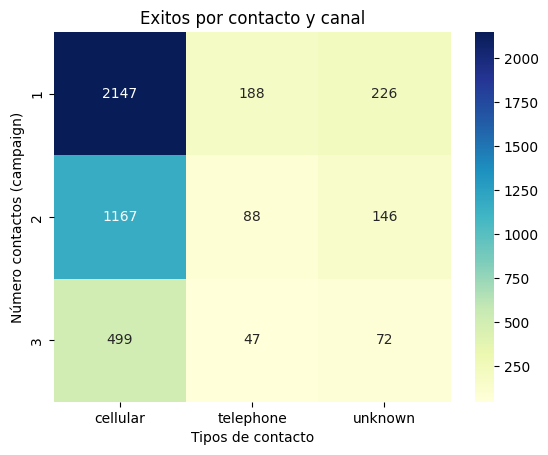

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

df_3 = df[df['campaign'] <= 3]
pivot = df_3[df_3['deposit'] == 'yes'].groupby(['campaign','contact']).size().unstack()

sns.heatmap(pivot, annot=True,fmt="d", cmap='YlGnBu')
plt.title('Exitos por contacto y canal')
plt.ylabel('Número contactos (campaign)')
plt.xlabel('Tipos de contacto')
plt.show()


### Exportamos a html

In [18]:
pip install mpld3


   ---------------------------------------- 0.0/203.1 kB ? eta -:--:--
   ---------------------------------------- 0.0/203.1 kB ? eta -:--:--
   -- ------------------------------------- 10.2/203.1 kB ? eta -:--:--
   -- ------------------------------------- 10.2/203.1 kB ? eta -:--:--
   ----- --------------------------------- 30.7/203.1 kB 187.9 kB/s eta 0:00:01
   ----------- --------------------------- 61.4/203.1 kB 328.2 kB/s eta 0:00:01
   ------------------------------------ - 194.6/203.1 kB 908.0 kB/s eta 0:00:01
   -------------------------------------- 203.1/203.1 kB 884.5 kB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\Portátil\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


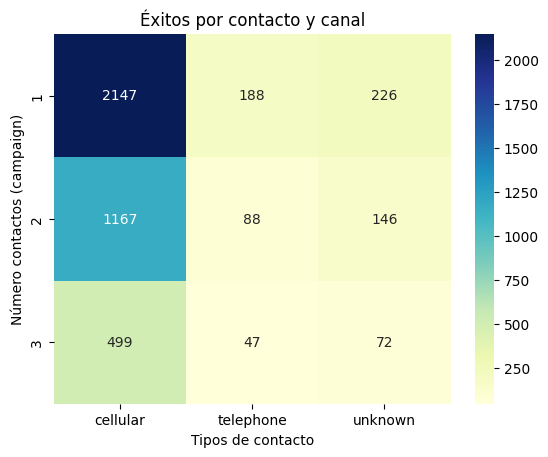

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
import mpld3

df_3 = df[df['campaign'] <= 3]
pivot = df_3[df_3['deposit'] == 'yes'].groupby(['campaign','contact']).size().unstack()

fig, ax = plt.subplots()
sns.heatmap(pivot, annot=True, fmt="d", cmap='YlGnBu', ax=ax)

ax.set_title('Éxitos por contacto y canal')
ax.set_ylabel('Número contactos (campaign)')
ax.set_xlabel('Tipos de contacto')

# Exportar a HTML
html_str = mpld3.fig_to_html(fig)
with open("heatmap_contactos.html", "w") as f:
    f.write(html_str)

plt.show()


In [16]:
import pandas as pd
from scipy.stats import chi2_contingency

# taula de contingència
table = pd.crosstab(df['contact'], df['deposit'])

# test chi-square
chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)
print("Expected frequencies:\n", expected)


Chi-square: 727.4951759856569
p-value: 1.062746611930725e-158
Degrees of freedom: 2
Expected frequencies:
 [[3876.67459124 3830.32540876]
 [ 371.7221387   367.2778613 ]
 [1104.60327006 1091.39672994]]


Con una tasa de éxito del 55,7%, necesitas unas 1,8 llamadas para conseguir un “sí”.
 Los primeros contactos (1, 2, 3…) tienen tasas de éxito más altas.  
  A medida que avanzan los contactos (8, 12, 13…), la tasa de éxito cae.  

### Conlusiones:
El análisis muestra que:
- La tasa de éxito es máxima con 1 contacto (55,77%)
- Con 2 y 3 contactos, el éxito se mantiene alto (48–49%)
- A partir de 4 contactos, la tasa de éxito disminuye progresivamente
- Entre 8 y 10 contactos, el éxito cae por debajo del 30%
- A partir de 12 contactos, prácticamente no hay conversiones

Esto, junto con una correlación negativa (–0,13), indica que realizar más contactos no mejora los resultados, sino que los empeora.

### Recomendación para optimizar la frecuencia de contacto:
- El punto óptimo se sitúa entre 1 y 3 contactos.
- A partir del cuarto contacto, la probabilidad de éxito disminuye de forma significativa.
- Recomendamos limitar la frecuencia de contacto - dentro del parámetro 1 a 3- para no incrementar el coste (tiempo y recuros del equipo) de la campaña; ni generar rechazo por parte del cliente.
- Priorizar la llamar a Cellular antes que el telephone.
- Cuanto más llamas, más intentos necesitas para conseguir un solo “sí” (ver tabla de conversión)